In [41]:
import os # files IO
import numpy as np # computation 
import pandas as pd # data manipulation & .csv IO
import matplotlib
import matplotlib.pyplot as plt # visualization 
import seaborn as sns # visualization
import shutil # copy & paste files
import kagglehub # load dataset
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from skimage.feature import hog

In [42]:
RANDOM_STATE = 42
CSV_PATH = 'CSV_FILES'
JOBLIB_PATH = 'JOBLIB_FILES'
os.makedirs(CSV_PATH, exist_ok=True)
os.makedirs(JOBLIB_PATH, exist_ok=True)

warnings.filterwarnings('ignore')

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover", "Dress",
    "Coat",
    "Sandal", "Shirt",
    "Sneaker", "Bag",
    "Ankle boot"
]

lr_params = {
    'random_state': RANDOM_STATE, 
    'n_jobs': 4,
    'max_iter': 2000,
    'C': 0.9,
}

# Fetch & Load Data

In [43]:
test_name = 'fashion-mnist_test.csv'
train_name = 'fashion-mnist_train.csv'
def fetch(): 
    train_path = os.path.join (os.getcwd(), train_name)
    test_path = os.path.join (os.getcwd(), test_name)
    if not (os.path.exists(train_name) and os.path.exists(test_name)): 
        source = kagglehub.dataset_download('zalando-research/fashionmnist')
        train_source = os.path.join (source, train_name)
        test_source = os.path.join (source, test_name)
        shutil.copy2 (train_source, train_path)
        shutil.copy2 (test_source, test_path)

    return train_path, test_path

def load(train_path, test_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    return train, test 

train_path, test_path = fetch()
data, test = load(train_path, test_path)

# Data Exploration & Experiments 

In [44]:
train_name = 'train.csv'
valid_name = 'valid.csv'
train_path = os.path.join (CSV_PATH, train_name)
valid_path = os.path.join (CSV_PATH, valid_name)

if not (os.path.exists(train_path) and os.path.exists(valid_path)): 
    train, valid = train_test_split(
        data, 
        test_size=10000, 
        shuffle = True, 
        random_state=RANDOM_STATE,
        stratify=data['label']
    )
    train.to_csv(train_path, index = False)
    valid.to_csv(valid_path, index = False)
else: 
    train, valid = pd.read_csv(train_path), pd.read_csv (valid_path) 

In [45]:
print ('train shape: ', train.shape) 
print ('valid shape: ', valid.shape) 
print ('test shape: ', test.shape)

train shape:  (50000, 785)
valid shape:  (10000, 785)
test shape:  (10000, 785)


In [46]:
x_train, y_train = train.drop('label', axis = 1).copy(), train['label'].copy()
x_valid, y_valid = valid.drop('label', axis = 1).copy(), valid['label'].copy()
x_test, y_test = test.drop('label', axis = 1).copy(), test['label'].copy()

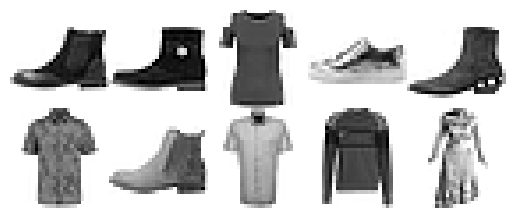

In [47]:
def plot_digits (instances): 
    image_per_row = min(len(instances), 5)
    images = [instance.reshape(28, 28) for instance in instances]
    n_rows = (len(instances) - 1) // image_per_row + 1
    row_images = []
    n_empty = n_rows * image_per_row - len(instances)
    images.append (np.zeros((28, 28 * n_empty)))  
    for row in range (n_rows): 
        rimages = images[row * image_per_row : (row + 1) * image_per_row]
        row_images.append (np.concatenate(rimages, axis = 1)) 

    image = np.concatenate (row_images, axis = 0) 
    plt.imshow (image, cmap = matplotlib.cm.binary) 
    plt.axis ('off')
plot_digits(x_train[:10].values)

# Raw Performance 

In [48]:
# Shrink train & Valid set by 5 times
train_small, _ = train_test_split(
    train, 
    train_size = 10000, 
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=train['label'], 
)

valid_small, _ = train_test_split(
    valid, 
    train_size = 2000, 
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=valid['label'], 
)
x_train_small, y_train_small = train_small.drop('label', axis = 1).copy(), train_small['label'].copy()
x_valid_small, y_valid_small = valid_small.drop('label', axis = 1).copy(), valid_small['label'].copy()

In [49]:
raw_model_path = os.path.join (JOBLIB_PATH, 'Raw_Model_Compressed.joblib')

if not os.path.exists(raw_model_path): 
    # Reduce size of train & valid sets by 5 times
    print ('Training & Predicting...', end =  ' ')
    raw_model = LogisticRegression (**lr_params)
    raw_model.fit (x_train_small, y_train_small)
    joblib.dump (raw_model, raw_model_path)
    print ('DONE')
else: 
    raw_model = joblib.load(raw_model_path)
pred = raw_model.predict(x_valid_small)

f1 = f1_score (y_valid_small, pred, average='macro')
acc = accuracy_score (y_valid_small, pred)
name = 'raw_compressed_data'
results = [[name, f1, acc]]

performance_df = pd.DataFrame(results, columns = ['name', 'f1', 'acc'])
performance_df

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675


# Experiment Normalizing Data

In [50]:
x_train_norm_small = x_train_small / 255.0
x_valid_norm_small = x_valid_small / 255.0

In [51]:
normalized_model_path = os.path.join (JOBLIB_PATH, 'Normalized_Model_Compressed.joblib')

if not os.path.exists(normalized_model_path): 
    model = LogisticRegression(**lr_params)
    model.fit (x_train_norm_small, y_train_small)
    joblib.dump(model, normalized_model_path)
else: 
    model = joblib.load (normalized_model_path)
    
pred = model.predict(x_valid_norm_small)
results_df = pd.DataFrame([{
    'name': 'normalized_compressed_data', 
    'f1': f1_score(y_valid_small, pred, average='macro'),
    'acc': accuracy_score(y_valid_small, pred), 
}])
performance_df = pd.concat ([performance_df, results_df], ignore_index=False)
performance_df.drop_duplicates(subset = 'name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345


# Experiment Scaling Data

In [52]:
scaler = StandardScaler()
x_train_scaled_small = scaler.fit_transform (x_train_small)
x_valid_scaled_small = scaler.transform (x_valid_small)

scaled_model_path = os.path.join (JOBLIB_PATH, 'Scaled_Model_Compressed.joblib')
if not os.path.exists(scaled_model_path): 
    model = LogisticRegression(**lr_params)
    model.fit (x_train_scaled_small, y_train_small)
    joblib.dump (model, scaled_model_path)
else: 
    model = joblib.load(scaled_model_path)
pred = model.predict(x_valid_scaled_small)
performance_df = pd.concat([
    performance_df,
    pd.DataFrame([{
        'name': 'scaled_compressed_data', 
        'f1': f1_score(y_valid_small, pred, average='macro'), 
        'acc': accuracy_score(y_valid_small, pred), 
    }])
], ignore_index=False)

performance_df.drop_duplicates(subset='name')
performance_df

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045


Normalization has better performance than Scaling

# Experiment Noise reduction with VarianceThreshold

In [53]:
thresholds = [0.00001, 0.0001, 0.001, 0.01]
variance_results = []

variance_result_path = os.path.join (CSV_PATH, 'variance_result.csv')
if not os.path.exists(variance_result_path): 
    for threshold in thresholds:
        pipe = Pipeline([
            ('variance', VarianceThreshold(threshold)),
            ('lr', LogisticRegression(**lr_params))
        ])
        pipe.fit(x_train_norm_small, y_train_small)
        pred = pipe.predict (x_valid_norm_small)
        
        f1 = f1_score(y_valid_small, pred, average='macro')
        acc = accuracy_score(y_valid_small, pred)
        print (threshold, ' ', f1, ' ', acc)

        variance_results.append([threshold, f1, acc])

    variance_result_df = pd.DataFrame(variance_results, columns = ['threshold', 'f1', 'acc'])
    variance_result_df.to_csv(variance_result_path)
else: 
    variance_result_df = pd.read_csv(variance_result_path)
variance_result_df

,Unnamed: 0,threshold,f1,acc
0,0,0.00001,0.838489,0.8405
1,1,0.00010,0.838684,0.8405
2,2,0.00100,0.838643,0.8405
3,3,0.01000,0.836100,0.8380


0.0001 is the best threshold

In [54]:
best_variance_threshold = 0.0001

In [55]:
performance_df = pd.concat([
    performance_df, 
    pd.DataFrame([{
        'name': 'variance_threshold_compressed_data',
        'f1': variance_result_df.iloc[1]['f1'],
        'acc': variance_result_df.iloc[1]['acc'],
    }])
], ignore_index=False)
performance_df.drop_duplicates(subset = 'name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


# Experiment on PCA with shrinked datasets

In [56]:
PCA_results = []
pca_result_path = os.path.join (CSV_PATH, 'PCA_result.csv')
if not os.path.exists(pca_result_path):
    for threshold in [0.85, 0.90, 0.95, 0.99]: 
        pipe = Pipeline ([
            ('variance', VarianceThreshold(best_variance_threshold)), 
            ('pca', PCA(n_components=threshold,  random_state=RANDOM_STATE,)),
            ('lr', LogisticRegression(**lr_params)), 
        ])

        pipe.fit (x_train_norm_small, y_train_small)
        pred = pipe.predict (x_valid_norm_small)
        acc = accuracy_score(y_valid_small, pred)
        f1 = f1_score(y_valid_small, pred, average='macro')

        print (threshold, ' ', f1, ' ', acc)
        PCA_results.append ([threshold, f1, acc])
    PCA_results_df = pd.DataFrame(PCA_results, columns = ['threshold', 'f1', 'acc'])
    PCA_results_df.to_csv(pca_result_path)
else:
    PCA_results_df = pd.read_csv(pca_result_path)
display(PCA_results_df)
display(performance_df)

,Unnamed: 0,threshold,f1,acc
0,0,0.85,0.824555,0.8260
1,1,0.90,0.833551,0.8350
2,2,0.95,0.837601,0.8380
3,3,0.99,0.833750,0.8355


,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


Adding PCA does not improve the performance 

# Evaluate on full train & valid sets

In [57]:
x_train_norm = x_train / 255.0
x_valid_norm = x_valid / 255.0

full_data_path = os.path.join (CSV_PATH, 'Full_Performane.csv')
full_model_path = os.path.join (JOBLIB_PATH, 'Full_Model.joblib')

if not (os.path.exists(full_data_path) and os.path.exists(full_model_path)): 
    pipe = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression(**lr_params)), 
    ])

    if not os.path.exists(full_model_path): 
        pipe.fit (x_train_norm, y_train)
        joblib.dump (pipe, full_model_path)
    else: 
        pipe = joblib.load (full_model_path)

    pred = pipe.predict(x_valid_norm)
    f1 = f1_score(y_valid, pred, average='macro')
    acc = accuracy_score(y_valid, pred)
    
    full_performance_df = pd.DataFrame([[
        'full_data_model', 
        f1, 
        acc, 
    ]], columns = ['name', 'f1', 'acc'])

    full_performance_df.to_csv(full_data_path)
else: 
    full_performance_df = pd.read_csv(full_data_path)

In [58]:
display(full_performance_df)
display(performance_df)

,Unnamed: 0,name,f1,acc
0,0,full_data_model,0.850789,0.8519


,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


Training on full set improves performance, meaning that the model is behaving well 

In [59]:
performance_df = pd.concat([
    performance_df,
    pd.DataFrame([{
        'name': 'full_model_performance', 
        'f1': full_performance_df.iloc[0]['f1'],
        'acc': full_performance_df.iloc[0]['acc'], 
    }])
], ignore_index=False)
performance_df.drop_duplicates(subset='name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405
0,full_model_performance,0.850789,0.8519


In [ ]:
pipe = joblib.load (full_model_path)
pred = pipe.predict(y_valid)
print ('Accuracy: ', accuracy_score(y_test, pred))
print (classification_report(y_test, pred))

ValueError: Found input variables with inconsistent numbers of samples: [10000, 2000]

Performance on full train - test set is apparently better: 0.8557 

On compressed sets, the accuracy was only 0.8446

# Confusion Matrix

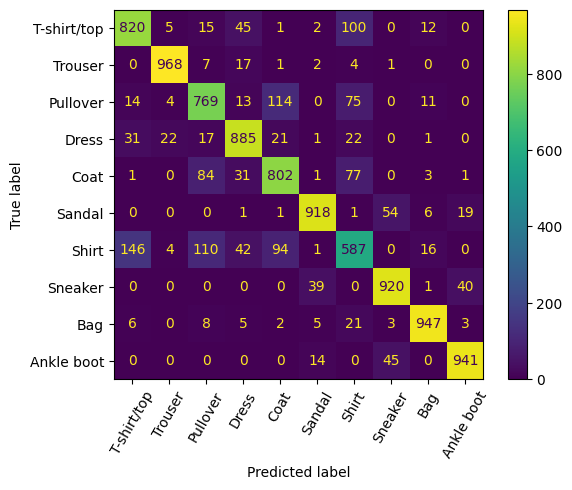

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    pred, 
    display_labels=class_names, 
)
plt.tick_params(axis = 'x', rotation = 60)
plt.show() 

Analysis: 
* Most confused feature is 'Shirt', classified as Tshirt/Coat, Pullover, Coat; Vice-versa
* Dress are mistaken from Tshirt/Coat, Shirt, Coat --> Weird

Conclusion: The model is mostly confused with upper-body clothes --> HOG can help

# HOG Feature Engineering

In [ ]:
def extract_hog_features(X):
    images = np.asarray(X).reshape(-1, 28, 28)
    features = [
        hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True,
        )
        for image in images
    ]
    return np.asarray(features, dtype=np.float32)


In [ ]:
hog_features_path = os.path.join(JOBLIB_PATH, 'HOG_Features.joblib')

if os.path.exists(hog_features_path):
    hog_features = joblib.load(hog_features_path)
    x_train_hog = hog_features['x_train_hog']
    x_valid_hog = hog_features['x_valid_hog']
else:
    print('Extracting HOG features...', end=' ')
    x_train_hog = extract_hog_features(x_train_norm)
    x_valid_hog = extract_hog_features(x_valid_norm)
    joblib.dump(
        {
            'x_train_hog': x_train_hog,
            'x_valid_hog': x_valid_hog,
        },
        hog_features_path,
    )
    print('DONE')

print('HOG train shape:', x_train_hog.shape)
print('HOG valid shape:', x_valid_hog.shape)


Extracting HOG features... DONE
HOG train shape: (10000, 1296)
HOG valid shape: (2000, 1296)


In [ ]:
hog_perf_path = os.path.join(CSV_PATH, 'HOG_Logistic_Performance.csv')
hog_model_path = os.path.join(JOBLIB_PATH, 'HOG_Logistic_Model.joblib')

if os.path.exists(hog_perf_path) and os.path.exists(hog_model_path):
    hog_lr = joblib.load(hog_model_path)
    hog_results_df = pd.read_csv(hog_perf_path)
else:
    print('Training HOG Logistic Regression...', end=' ')
    hog_lr = LogisticRegression(**lr_params)
    hog_lr.fit(x_train_hog_small, y_train_small)
    pred_hog = hog_lr.predict(x_valid_hog_small)
    print('DONE')

    hog_results_df = pd.DataFrame([{
        'name': 'hog_logistic_regression',
        'features': x_train_hog_small.shape[1],
        'f1': f1_score(y_valid_small, pred_hog, average='macro'),
        'acc': accuracy_score(y_valid_small, pred_hog),
    }])
    hog_results_df.to_csv(hog_perf_path, index=False)
    joblib.dump(hog_lr, hog_model_path)

hog_results_df


Training HOG Logistic Regression... DONE


,name,features,f1,acc
0,hog_logistic_regression,1296,0.858861,0.86


In [ ]:
performance_df = pd.concat(
    [performance_df, hog_results_df],
    ignore_index=True,
).drop_duplicates(subset='name')

performance_df

,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,"0 0.850789 Name: f1, dtype: float64","0 0.8519 Name: acc, dtype: float64",NaN
5,full_model_performance1,0.850789,0.8519,NaN
6,hog_logistic_regression,0.858861,0.86,1296.0
